# Week 6: Linear Regression & Model Interpretation

This notebook explores the core concepts of linear regression. We analyze real world datasets from Week 5 (IMF World Economic Outlook and World Happiness Report) to explore the relation between country wealth and happiness.

This notebook has **three parts**:

1. **Part 1: Real World Regression (Happiness vs. GDP per Capita)**: Clean and merge datasets by country, create exploratory scatter plots, and fit a best fit regression line through actual data.
2. **Part 2: Model Interpretation & Specifications**: Compare and interpret four standard regression specifications (Level to Level, Level to Log, Log to Level, and Log to Log) using a dedicated interpretation utility function.
3. **Part 3: Appendix: Ordinary Least Squares (OLS) Fundamentals (Optional)**: Learn how OLS is solved under the hood. Using our country dataset, we calculate regression coefficients by hand, compare them with statsmodels, visualize regression errors, and solve OLS using matrix algebra.
<hr>


# 1.1 Happiness vs. GDP per Capita

We start by loading and merging our real datasets from Week 5: the IMF World Economic Outlook database and the World Happiness Report.


### 1.1.A Load and Merge Datasets

We load the datasets from `data/examples/week_5/`, clean the column names, and merge them for the year 2023.


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load week 5 datasets
df_happy = pd.read_parquet("../../data/examples/week_5/world_happiness.parquet")
df_imf_raw = pd.read_parquet("../../data/examples/week_5/imf_weo_countries.parquet")
df_imf_raw.head(2)

,weo_country_code,iso,weo_subject_code,country,subject_descriptor,subject_notes,units,scale,country_series-specific_notes,estimates_start_after,unnamed:_60,year,value
0,512,AFG,NGDP_R,Afghanistan,"Gross domestic product, constant prices",Expressed in billions of national currency uni...,National currency,Billions,Source: National Statistics Office Latest actu...,2024,None,1980,NaN
1,512,AFG,NGDP_RPCH,Afghanistan,"Gross domestic product, constant prices",Annual percentages of constant price GDP are y...,Percent change,Units,"See notes for: Gross domestic product, consta...",2024,None,1980,NaN


In [25]:

# Process IMF dataset: clean columns and filter for GDP per capita (NGDPDPC) in 2023
df_imf_raw.columns = df_imf_raw.columns.str.lower().str.replace(" ", "_")
df_imf_raw.columns


Index(['weo_country_code', 'iso', 'weo_subject_code', 'country',
       'subject_descriptor', 'subject_notes', 'units', 'scale',
       'country_series-specific_notes', 'estimates_start_after', 'unnamed:_60',
       'year', 'value'],
      dtype='object')

In [26]:
df_gdp_2023 = df_imf_raw.query("weo_subject_code == 'NGDPDPC' and year == 2023")[['country', 'value']].dropna()
df_gdp_2023

,country,value
370884,Afghanistan,410.933
370928,Albania,8299.278
370972,Algeria,5221.813
371016,Andorra,43809.726
371060,Angola,2967.384
...,...,...
379288,Vietnam,4324.049
379332,West Bank and Gaza,3180.667
379376,Yemen,551.953
379420,Zambia,1369.129


In [27]:
df_gdp_2023 = df_gdp_2023.rename(columns={'country': 'country_name', 'value': 'gdp_per_capita'})
df_gdp_2023.head(2)

,country_name,gdp_per_capita
370884,Afghanistan,410.933
370928,Albania,8299.278


In [28]:

# Merge datasets by country
df_merged = pd.merge(df_happy, df_gdp_2023, on='country_name')
df_merged = df_merged[['country_name', 'ladder_score', 'gdp_per_capita']].dropna()
print(f"Total merged records: {len(df_merged)}")
df_merged.head(5)


Total merged records: 129


,country_name,ladder_score,gdp_per_capita
0,Finland,7.7407,53130.693
1,Denmark,7.5827,68618.872
2,Iceland,7.5251,83485.110
3,Sweden,7.3441,55433.135
4,Israel,7.3411,52643.451


### 1.1.1 Exploratory Scatter Plot

We first inspect the relationship visually by creating a scatter plot.


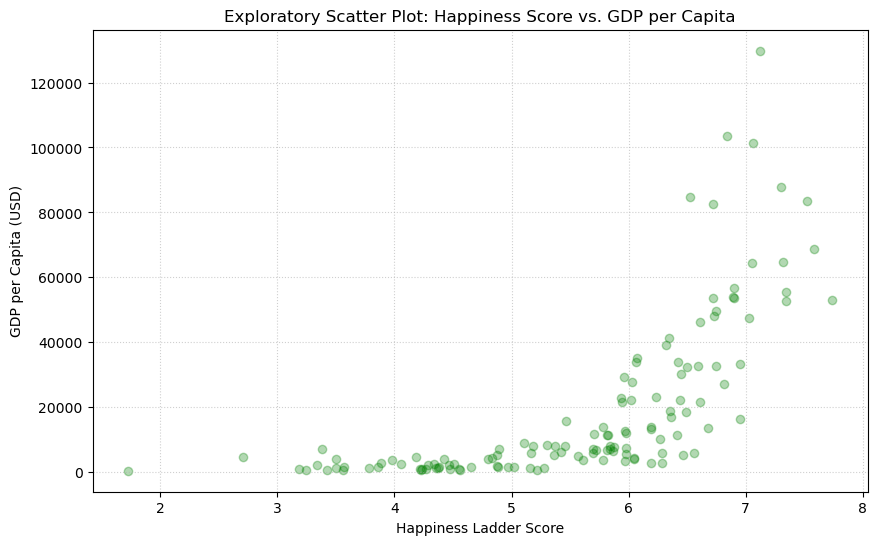

In [29]:
plt.figure(figsize=(10, 6))
plt.scatter(x = df_merged['ladder_score'], y =df_merged['gdp_per_capita'], color='green', alpha=0.3)


plt.title("Exploratory Scatter Plot: Happiness Score vs. GDP per Capita")
plt.ylabel("GDP per Capita (USD)")
plt.xlabel("Happiness Ladder Score")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### 1.1.2 Fitting the Regression Line

We fit a simple linear regression model to the merged data and draw the best fit regression line directly through our scatter plot.


In [30]:
import statsmodels.api as sm

# Keep original setup: Happiness predicts GDP
X_real = df_merged['ladder_score']
y_real = df_merged['gdp_per_capita']
X_real_const = sm.add_constant(X_real)
X_real_const.head

<bound method NDFrame.head of      const  ladder_score
0      1.0        7.7407
1      1.0        7.5827
2      1.0        7.5251
3      1.0        7.3441
4      1.0        7.3411
..     ...           ...
124    1.0        3.3411
125    1.0        3.2452
126    1.0        3.1862
127    1.0        2.7065
128    1.0        1.7210

[129 rows x 2 columns]>

In [31]:
model_real = sm.OLS(y_real, X_real_const).fit()
model_real

### 1.1.3 Show regression line

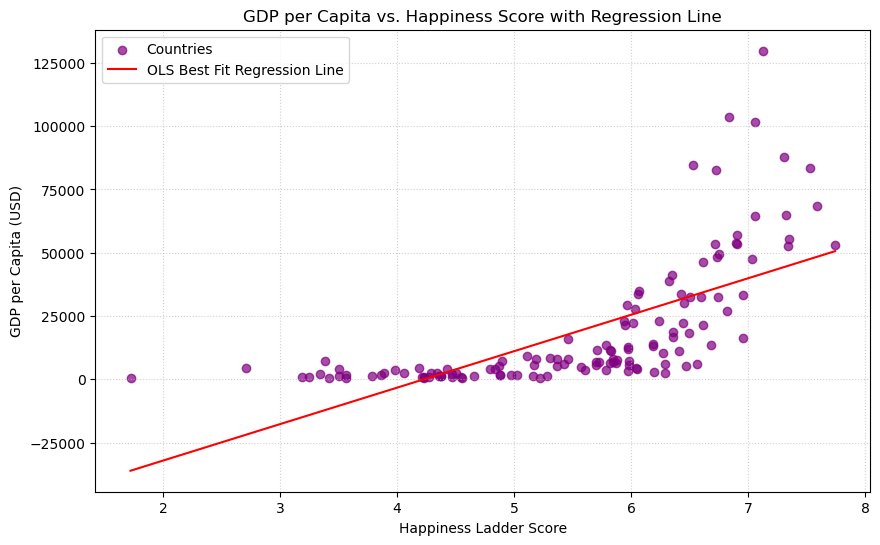

In [32]:

plt.figure(figsize=(10, 6))

# 1. X is Happiness, Y is GDP
plt.scatter(df_merged['ladder_score'], df_merged['gdp_per_capita'], color='purple', alpha=0.7, label='Countries')


intercept_real, slope_real = model_real.params.iloc[0], model_real.params.iloc[1]

# 2. Match the regression line calculation to the X values (ladder_score)
plt.plot(df_merged['ladder_score'], intercept_real + slope_real * df_merged['ladder_score'], color='red', label='OLS Best Fit Regression Line')

# 3. Label the axes correctly
plt.title("GDP per Capita vs. Happiness Score with Regression Line")
plt.xlabel("Happiness Ladder Score")
plt.ylabel("GDP per Capita (USD)")

plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### 1.1.4 Show regression line with interpretation

In [33]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
# Flip axes: Happiness on X (Independent), GDP on Y (Dependent)
X = sm.add_constant(df_merged["ladder_score"])
model = sm.OLS(df_merged["gdp_per_capita"], X).fit()
b0, b1 = model.params.iloc[0], model.params.iloc[1]
# Set clean arrow coordinates for a 1-unit increase in happiness
x1 = df_merged["ladder_score"].mean()
x2 = x1 + 1
y1 = b0 + b1 * x1
y2 = y1 + b1

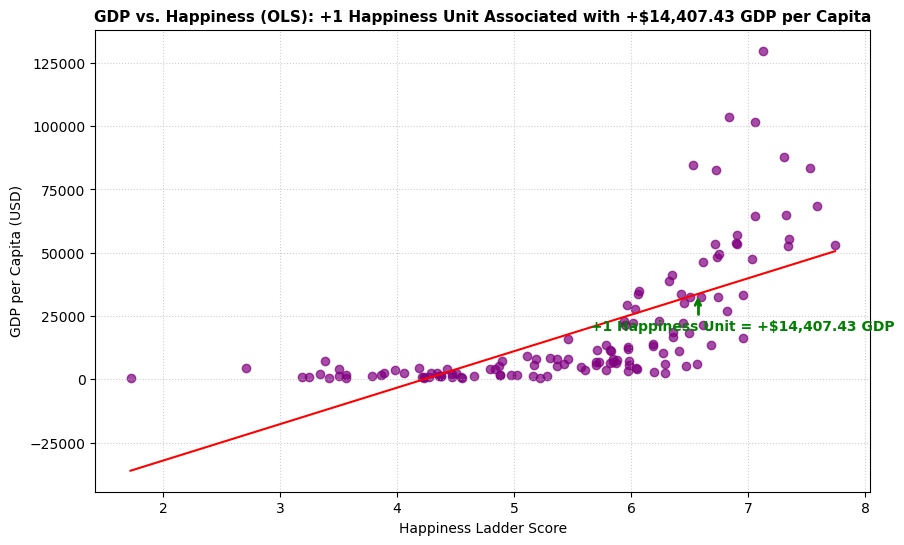

In [34]:
# Plot
plt.figure(figsize=(10, 6))
plt.scatter(df_merged["ladder_score"],df_merged["gdp_per_capita"],color="purple",alpha=0.7,)
plt.plot(df_merged["ladder_score"], b0 + b1 * df_merged["ladder_score"], color="red")

# One clean step arrow: moves right 1 unit, then up by the slope value
plt.annotate(f"  +1 Happiness Unit = +${b1:,.2f} GDP",xy=(x2, y2),xytext=(x1, y1),arrowprops=dict(arrowstyle="->", connectionstyle="angle,angleA=0,angleB=90", color="green", lw=2),weight="bold",color="green",)

plt.title(f"GDP vs. Happiness (OLS): +1 Happiness Unit Associated with +${b1:,.2f} GDP per Capita",fontsize=11,weight="bold",)
plt.xlabel("Happiness Ladder Score")
plt.ylabel("GDP per Capita (USD)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

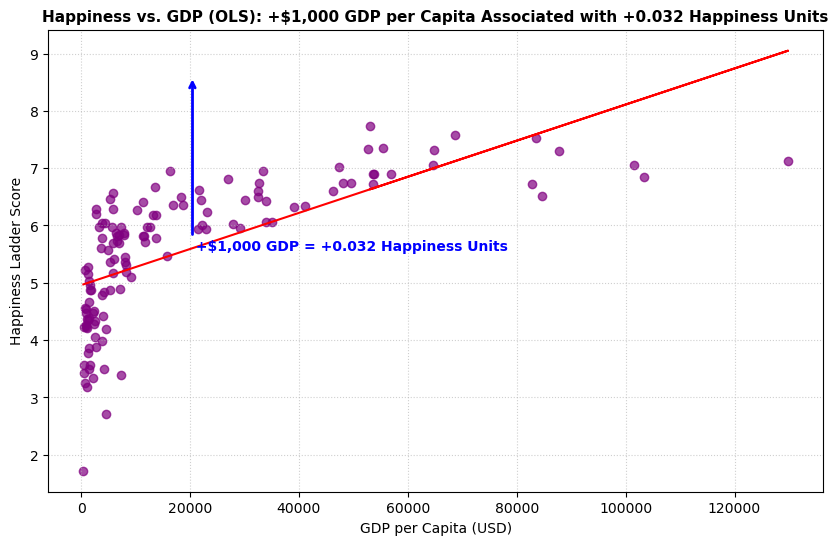

In [35]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

X = sm.add_constant(df_merged["gdp_per_capita"])
model = sm.OLS(df_merged["ladder_score"], X).fit()
b0, b1 = model.params.iloc[0], model.params.iloc[1]

x1 = df_merged["gdp_per_capita"].mean()
x2 = x1 + 1000
y1 = b0 + b1 * x1
y2 = y1 + b1 * 1000

plt.figure(figsize=(10, 6))
plt.scatter(df_merged["gdp_per_capita"], df_merged["ladder_score"], color="purple", alpha=0.7)
plt.plot(df_merged["gdp_per_capita"], b0 + b1 * df_merged["gdp_per_capita"], color="red")

plt.annotate(f"  +$1,000 GDP = +{b1 * 1000:.3f} Happiness Units", xy=(x2+100, y2+3), xytext=(x1, y1), arrowprops=dict(arrowstyle="->", connectionstyle="angle,angleA=0,angleB=90", color="blue", lw=2), weight="bold", color="blue")

plt.title(f"Happiness vs. GDP (OLS): +$1,000 GDP per Capita Associated with +{b1 * 1000:.3f} Happiness Units", fontsize=11, weight="bold")
plt.xlabel("GDP per Capita (USD)")
plt.ylabel("Happiness Ladder Score")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

## 1.2 Revenue vs. GDP

### 1.2.A download

In [36]:
import requests
import pandas as pd
import io
import matplotlib.pyplot as plt
import seaborn as sns

def download_worldbank(indicator, countries, date_start, date_end):
    url_base = 'https://api.worldbank.org/v2/'
    country_codes = ';'.join(countries)
    url = f'{url_base}country/{country_codes}/indicator/{indicator}?date={date_start}:{date_end}&per_page=30000'
    response = requests.get(url)
    df = pd.read_xml(io.BytesIO(response.content))
    return df

# 1. Fetch the data for all countries (using 2022 as a recent complete year)
print("Fetching revenue data...")
df_revenue = download_worldbank('GC.REV.XGRT.GD.ZS', ['all'], 2022, 2022)

print("Fetching income data...")
df_income = download_worldbank('NY.GDP.PCAP.PP.CD', ['all'], 2022, 2022)

Fetching revenue data...
Fetching income data...


In [37]:
# 2. Clean and rename columns for merging
# Note: World Bank XML structure uses namespaces or specific tags like 'country' and 'value'
df_rev_clean = df_revenue[['country', 'value']].rename(columns={'value': 'Revenue_pct_GDP'})
df_inc_clean = df_income[['country', 'value']].rename(columns={'value': 'GDP_per_Capita'})

# Extract country name text from the XML element object if necessary, 
# or merge directly if they are strings. Assuming standard read_xml flattening:
df_merged = pd.merge(df_rev_clean, df_inc_clean, on='country').dropna().query("country != 'Nauru'")
df_merged.head(2)

,country,Revenue_pct_GDP,GDP_per_Capita
0,Africa Eastern and Southern,23.127646,4369.191056
4,Central Europe and the Baltics,34.851909,45290.566661


In [39]:
print(df_merged.columns.tolist())

['country', 'Revenue_pct_GDP', 'GDP_per_Capita']


### 1.2.1 Scatter 

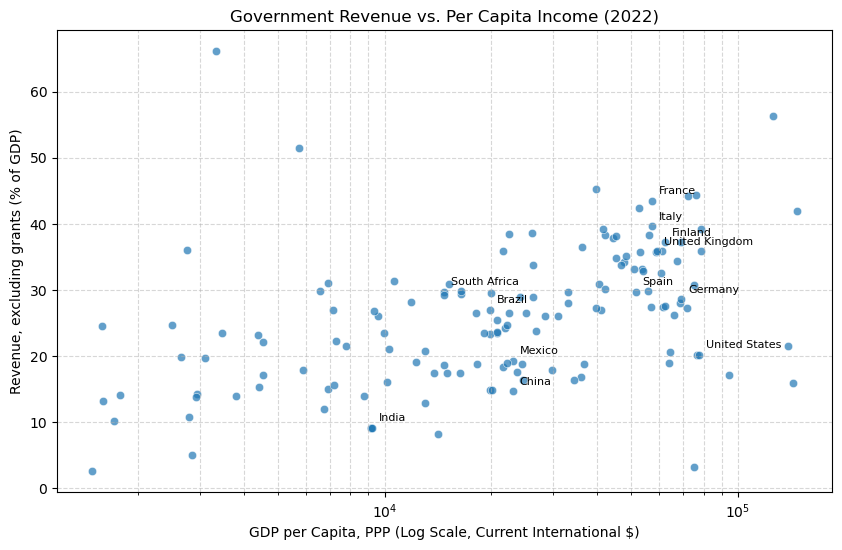

In [42]:
# 3. Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_merged, 
    x='GDP_per_Capita', 
    y='Revenue_pct_GDP', 
    alpha=0.7, 
    edgecolor='w'
)

# Apply a log scale to income since GDP per capita spans from under $1,000 to over $100,000
plt.xscale('log')
plt.title('Government Revenue vs. Per Capita Income (2022)')
plt.xlabel('GDP per Capita, PPP (Log Scale, Current International $)')
plt.ylabel('Revenue, excluding grants (% of GDP)')
plt.grid(True, which="both", ls="--", alpha=0.5)

# Optional: Label a few outliers or notable points
for _, row in df_merged.iterrows():
    if row['country'] in ['Finland', 'Spain', 'United States', 'China', 'Germany', 'India', 'Brazil', 'South Africa','France','United Kingdom','Japan','Italy','Russia','Mexico','Indonesia','Turkey']:
        plt.annotate(
            row['country'],
            (row['GDP_per_Capita'], row['Revenue_pct_GDP']),  # match your exact column names
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8
        )

plt.show()

### 1.2.2 Show regression line with interpretation

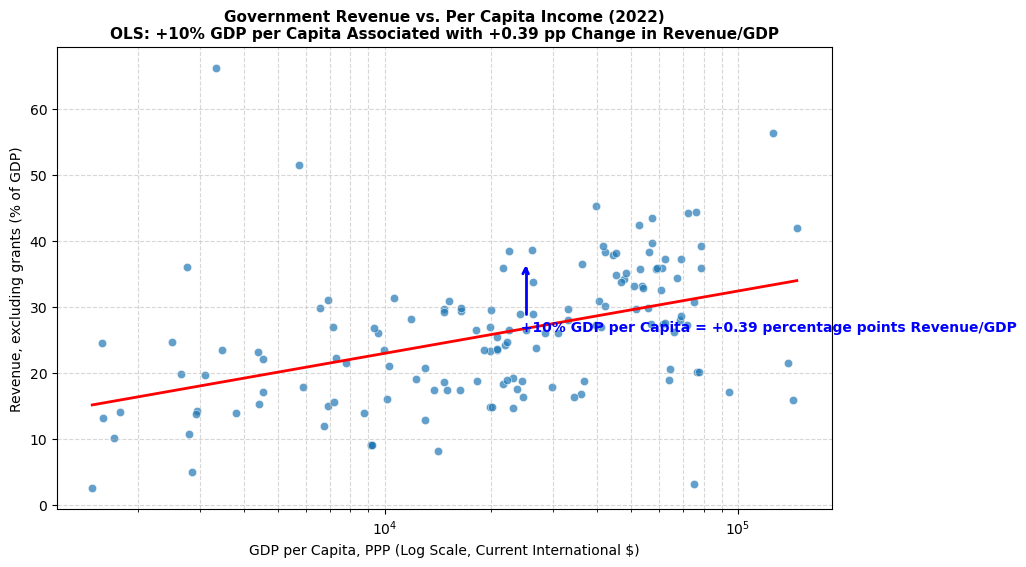

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.api as sm

# Fit log-linear OLS model: Revenue (% of GDP) = b0 + b1 * log(GDP_per_Capita)
# Log-transforming X accounts for the large cross-country income variance (under $1k to over $100k)
X = sm.add_constant(np.log(df_merged["GDP_per_Capita"]))
model = sm.OLS(df_merged["Revenue_pct_GDP"], X).fit()
b0, b1 = model.params.iloc[0], model.params.iloc[1]

# Calculate coordinates for a 10% increase in GDP per capita to anchor the annotation arrow
# In a log-linear model, a 10% increase in X yields a (b1 * ln(1.10)) change in Y
x1 = df_merged["GDP_per_Capita"].median()
x2 = x1 * 1.10
y1 = b0 + b1 * np.log(x1)
y2 = b0 + b1 * np.log(x2)
y_delta = y2 - y1

# Plot base scatter
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_merged,
    x="GDP_per_Capita",
    y="Revenue_pct_GDP",
    alpha=0.7,
    edgecolor="w",
)

# Plot the OLS log-linear regression curve
x_domain = np.linspace(
    df_merged["GDP_per_Capita"].min(), df_merged["GDP_per_Capita"].max(), 500
)
plt.plot(x_domain, b0 + b1 * np.log(x_domain), color="red", lw=2)

# Apply log scale to accommodate wide distribution of per capita income
plt.xscale("log")

# Annotate the step: moves right by 10% on log X, then up/down by the calculated revenue delta
plt.annotate(
    f"  +10% GDP per Capita = {y_delta:+.2f} percentage points Revenue/GDP",
    xy=(x2+10, y2+10),
    xytext=(x1, y1),
    arrowprops=dict(
        arrowstyle="->",
        connectionstyle="angle,angleA=0,angleB=90",
        color="blue",
        lw=2,
    ),
    weight="bold",
    color="blue",
)

plt.title(
    f"Government Revenue vs. Per Capita Income (2022)\nOLS: +10% GDP per Capita Associated with {y_delta:+.2f} pp Change in Revenue/GDP",
    fontsize=11,
    weight="bold",
)
plt.xlabel("GDP per Capita, PPP (Log Scale, Current International $)")
plt.ylabel("Revenue, excluding grants (% of GDP)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# ADVANCED: For beginners skip this next part and focus on reviews 

# 2. Model Interpretation & Specifications

Not all relationships are purely linear. In economics and public policy, variables are often transformed using logarithms to model percentage changes and elasticities. We will examine four specifications:

1. **Level to Level**: Standard linear relationship ($y = \alpha + \beta x$).
2. **Level to Log**: Independent variable is log transformed ($y = \alpha + \beta \ln(x)$).
3. **Log to Level**: Dependent variable is log transformed ($\ln(y) = \alpha + \beta x$).
4. **Log to Log**: Both variables are log transformed ($\ln(y) = \alpha + \beta \ln(x)$).


## 2.1 Creating Log Transformed Features

We apply natural log transforms to our target columns.


In [ ]:
df_merged.head(2)

,country,Revenue_pct_GDP,GDP_per_Capita
0,Africa Eastern and Southern,23.127646,4369.191056
4,Central Europe and the Baltics,34.851909,45290.566661


In [ ]:
df_merged = pd.merge(df_happy, df_gdp_2023, on='country_name')
df_merged = df_merged[['country_name', 'ladder_score', 'gdp_per_capita']].dropna()
df_merged.head(2)

,country_name,ladder_score,gdp_per_capita
0,Finland,7.7407,53130.693
1,Denmark,7.5827,68618.872


In [ ]:
# Add log transformed columns
df_merged['gdp_log'] = np.log(df_merged['gdp_per_capita'])
df_merged['ladder_log'] = np.log(df_merged['ladder_score'])
df_merged.head(2)


,country_name,ladder_score,gdp_per_capita,gdp_log,ladder_log
0,Finland,7.7407,53130.693,10.880510,2.046492
1,Denmark,7.5827,68618.872,11.136323,2.025869


## 2.2 Defining the Regression Interpretation Utility

We define a helper function to run regressions and output the exact mathematical and economic interpretation of the coefficients without any OOP code.


In [ ]:
import statsmodels.api as sm

def run_regression(data, y_col, x_col):
    y_series = data[y_col]
    x_series = data[x_col]
    x_with_const = sm.add_constant(x_series)
    model = sm.OLS(y_series, x_with_const).fit()
    return model

In [ ]:
model = run_regression(df_merged, 'gdp_per_capita', 'ladder_score')
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         gdp_per_capita   R-squared:                       0.454
Model:                            OLS   Adj. R-squared:                  0.450
Method:                 Least Squares   F-statistic:                     105.6
Date:                Fri, 22 May 2026   Prob (F-statistic):           2.15e-18
Time:                        11:48:40   Log-Likelihood:                -1452.2
No. Observations:                 129   AIC:                             2908.
Df Residuals:                     127   BIC:                             2914.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         -6.09e+04   7983.980     -7.628      0.000   -7.67e+04   -4.51e+04
ladder_score  1.441e+04   1402.223     10.275      0.000    1.16e+04    1.72e+04
==============================================================================
Omnibus:                       57.390   Durbin-Watson:                   0.889
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              170.128
Skew:                           1.714   Prob(JB):                     1.14e-37
Kurtosis:                       7.462   Cond. No.                         28.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 2.3 Comparing the Four Specifications

In [ ]:
import sys
sys.path.insert(0, "../..")
from src.model.regression import interpret_regression

In [ ]:
data = df_merged
# 1. LEVEL to LEVEL
model_ll = run_regression(data, y_col='ladder_score', x_col='gdp_per_capita')
interpret_regression(
    model_ll,
    x_col='gdp_per_capita',
    y_type='level',
    x_type='level',
    y_name='Happiness Score',
    x_name='GDP per capita'
)



=== Regression Interpretation: Happiness Score vs. GDP per capita ===
Specification: LEVEL to LEVEL
Coefficient: 0.000032
Interpretation: A 1 unit increase in GDP per capita is associated with a 0.000032 unit change in Happiness Score.
R squared (Fit quality): 0.4539
p value (Statistical significance): 0.0000


In [ ]:
# 2. LOG to LOG
model_lglg = run_regression(data, y_col='ladder_log', x_col='gdp_log')
interpret_regression(
    model_lglg,
    x_col='gdp_log',
    y_type='log',
    x_type='log',
    y_name='Happiness',
    x_name='GDP'
)



=== Regression Interpretation: Happiness vs. GDP ===
Specification: LOG to LOG
Coefficient: 0.132830
Interpretation: A 1% increase in GDP is associated with a 0.1328% change in Happiness.
R squared (Fit quality): 0.6234
p value (Statistical significance): 0.0000


In [ ]:
# 3. LEVEL to LOG
model_lgl = run_regression(data, y_col='ladder_score', x_col='gdp_log')
interpret_regression(
    model_lgl,
    x_col='gdp_log',
    y_type='level',
    x_type='log',
    y_name='Happiness Score',
    x_name='GDP'
)


=== Regression Interpretation: Happiness Score vs. GDP ===
Specification: LEVEL to LOG
Coefficient: 0.685011
Interpretation: A 1% increase in GDP is associated with a 0.0069 unit change in Happiness Score.
R squared (Fit quality): 0.7020
p value (Statistical significance): 0.0000


In [ ]:
# 4. LOG to LEVEL
model_lglvl = run_regression(data, y_col='ladder_log', x_col='gdp_per_capita')
interpret_regression(
    model_lglvl,
    x_col='gdp_per_capita',
    y_type='log',
    x_type='level',
    y_name='Log Happiness',
    x_name='GDP per capita'
)


=== Regression Interpretation: Log Happiness vs. GDP per capita ===
Specification: LOG to LEVEL
Coefficient: 0.000006
Interpretation: A 1 unit increase in GDP per capita is associated with a 0.0006% change in Log Happiness.
R squared (Fit quality): 0.3594
p value (Statistical significance): 0.0000


## 2.4 Visualizing the Four Specifications Side by Side

We create a grid of plots to visualize how each model behaves. Notice how using the log of GDP per capita straightens out the curvature, showing a highly linear relationship with happiness!


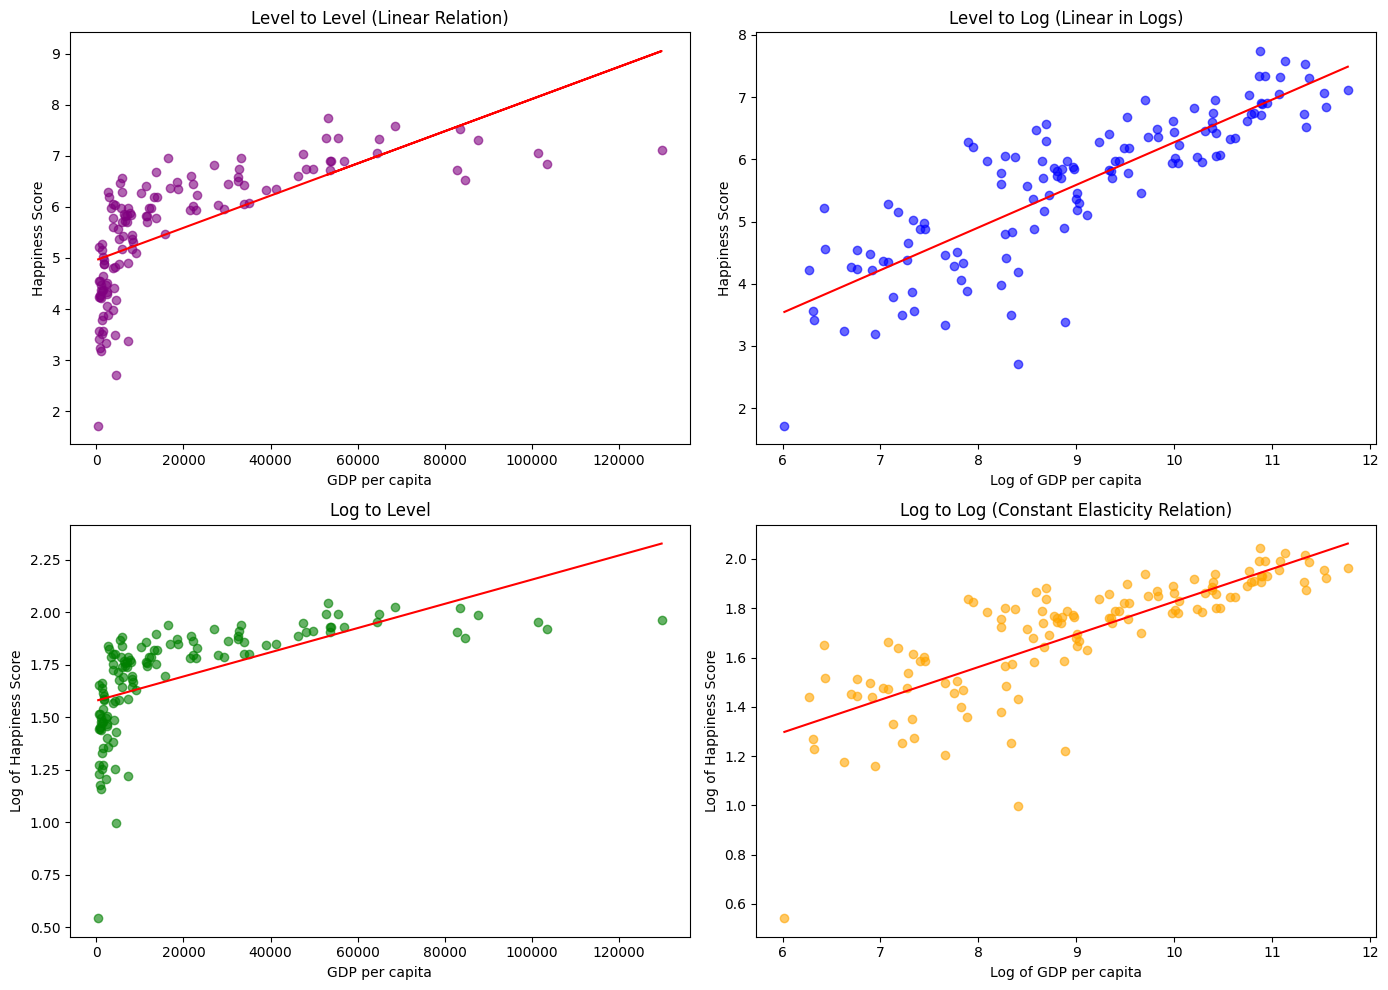

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Level to Level
axes[0, 0].scatter(df_merged['gdp_per_capita'], df_merged['ladder_score'], color='purple', alpha=0.6)
m_ll = sm.OLS(df_merged['ladder_score'], sm.add_constant(df_merged['gdp_per_capita'])).fit()
axes[0, 0].plot(df_merged['gdp_per_capita'], m_ll.params.iloc[0] + m_ll.params.iloc[1] * df_merged['gdp_per_capita'], color='red')
axes[0, 0].set_title("Level to Level (Linear Relation)")
axes[0, 0].set_xlabel("GDP per capita")
axes[0, 0].set_ylabel("Happiness Score")

# 2. Level to Log
axes[0, 1].scatter(df_merged['gdp_log'], df_merged['ladder_score'], color='blue', alpha=0.6)
m_l_log = sm.OLS(df_merged['ladder_score'], sm.add_constant(df_merged['gdp_log'])).fit()
sort_gdp = df_merged.sort_values('gdp_log')
axes[0, 1].plot(sort_gdp['gdp_log'], m_l_log.params.iloc[0] + m_l_log.params.iloc[1] * sort_gdp['gdp_log'], color='red')
axes[0, 1].set_title("Level to Log (Linear in Logs)")
axes[0, 1].set_xlabel("Log of GDP per capita")
axes[0, 1].set_ylabel("Happiness Score")

# 3. Log to Level
axes[1, 0].scatter(df_merged['gdp_per_capita'], df_merged['ladder_log'], color='green', alpha=0.6)
m_log_l = sm.OLS(df_merged['ladder_log'], sm.add_constant(df_merged['gdp_per_capita'])).fit()
sort_gdp_pc = df_merged.sort_values('gdp_per_capita')
axes[1, 0].plot(sort_gdp_pc['gdp_per_capita'], m_log_l.params.iloc[0] + m_log_l.params.iloc[1] * sort_gdp_pc['gdp_per_capita'], color='red')
axes[1, 0].set_title("Log to Level")
axes[1, 0].set_xlabel("GDP per capita")
axes[1, 0].set_ylabel("Log of Happiness Score")

# 4. Log to Log
axes[1, 1].scatter(df_merged['gdp_log'], df_merged['ladder_log'], color='orange', alpha=0.6)
m_log_log = sm.OLS(df_merged['ladder_log'], sm.add_constant(df_merged['gdp_log'])).fit()
sort_gdp_l = df_merged.sort_values('gdp_log')
axes[1, 1].plot(sort_gdp_l['gdp_log'], m_log_log.params.iloc[0] + m_log_log.params.iloc[1] * sort_gdp_l['gdp_log'], color='red')
axes[1, 1].set_title("Log to Log (Constant Elasticity Relation)")
axes[1, 1].set_xlabel("Log of GDP per capita")
axes[1, 1].set_ylabel("Log of Happiness Score")

plt.tight_layout()
plt.show()


# Part 3: Appendix: Ordinary Least Squares (OLS) Fundamentals (Optional)

In this optional section, we explore the mathematics of OLS from first principles using our actual merged country dataset (Happiness vs. GDP per capita).


## 3.1 Calculating OLS Coefficients by Hand

Using our real data, we calculate the covariance and variance of `gdp_per_capita` and `ladder_score` to find the slope (beta) and intercept (alpha) coefficients manually:

$$\hat\beta = \frac{Cov(x, y)}{Var(x)}$$
$$\hat\alpha = \bar{y} - \hat\beta \bar{x}$$


In [ ]:
# Calculate means of our real variables
x_mean = df_merged['gdp_per_capita'].mean()
y_mean = df_merged['ladder_score'].mean()
x_mean

np.float64(19331.147077519377)

In [ ]:

# Calculate differences from the mean
df_merged['xt'] = df_merged['gdp_per_capita'] - x_mean
df_merged['yt'] = df_merged['ladder_score'] - y_mean
df_merged['xt2'] = df_merged['xt'] ** 2
df_merged.head(2)

,country_name,ladder_score,gdp_per_capita,gdp_log,ladder_log,xt,yt,xt2
0,Finland,7.7407,53130.693,10.880510,2.046492,33799.545922,2.171866,1.142409e+09
1,Denmark,7.5827,68618.872,11.136323,2.025869,49287.724922,2.013866,2.429280e+09


In [ ]:

# Calculate slope (beta) and intercept (alpha) by hand
beta_hand = sum(df_merged['xt'] * df_merged['yt']) / sum(df_merged['xt2'])
beta_hand

3.1506451215922014e-05

In [ ]:
alpha_hand = y_mean - beta_hand * x_mean

print("Calculated by hand on real country data:")
print(f"Beta (slope) = {beta_hand:.8f}")
print(f"Alpha (intercept) = {alpha_hand:.4f}")


Calculated by hand on real country data:
Beta (slope) = 0.00003151
Alpha (intercept) = 4.9598


## 3.2 Verifying with Statsmodels

We verify that our manual coefficients match statsmodels exactly.


In [ ]:
X_append = df_merged['gdp_per_capita']
X_append_const = sm.add_constant(X_append)
y_append = df_merged['ladder_score']

ols_append = sm.OLS(y_append, X_append_const).fit()
beta_model = ols_append.params.iloc[1]
alpha_model = ols_append.params.iloc[0]

print("Calculated using Statsmodels:")
print(f"Beta (slope) = {beta_model:.8f}")
print(f"Alpha (intercept) = {alpha_model:.4f}")


Calculated using Statsmodels:
Beta (slope) = 0.00003151
Alpha (intercept) = 4.9598


## 3.3 Visualizing OLS Errors (TSS, ESS, RSS) on Real Data

We visualize the Total Sum of Squares (TSS), Explained Sum of Squares (ESS), and Residual Sum of Squares (RSS).

To keep the visualization clean and readable, we display the error arrows for a representative sample of 15 countries. We scale the arrow widths to fit the scale of the GDP per capita axis.


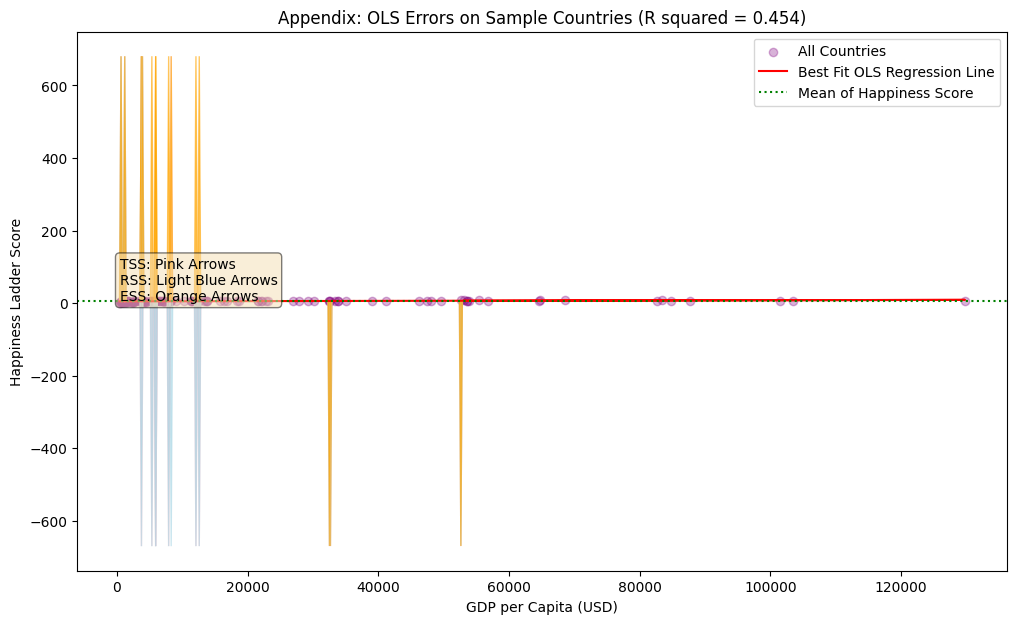

In [ ]:
# Calculate predicted values, residuals, and mean for the full dataset
df_merged['y_hat'] = alpha_hand + df_merged['gdp_per_capita'] * beta_hand
df_merged['u_hat'] = df_merged['ladder_score'] - df_merged['y_hat']
df_merged['y_mean'] = y_mean

# Sum of Squares
ess = sum((df_merged['y_hat'] - y_mean) ** 2)
rss = sum((df_merged['ladder_score'] - df_merged['y_hat']) ** 2)
tss = sum((df_merged['ladder_score'] - y_mean) ** 2)
r2 = 1 - rss / tss

# Set up the background plot with all countries
plt.figure(figsize=(12, 7))
plt.scatter(df_merged['gdp_per_capita'], df_merged['ladder_score'], color='purple', alpha=0.3, label='All Countries')
plt.plot(df_merged['gdp_per_capita'], df_merged['y_hat'], color='red', label='Best Fit OLS Regression Line')
plt.axhline(y_mean, color='green', linestyle=':', label='Mean of Happiness Score')

# Draw arrows for a sample of 15 countries to keep the graph legible
np.random.seed(42)
df_sample = df_merged.sample(15)
x_sample = df_sample['gdp_per_capita'].values
y_sample = df_sample['ladder_score'].values
y_hat_sample = df_sample['y_hat'].values

for i in range(len(df_sample)):
    # TSS arrow (pink) - representing distance from the mean of Y
    plt.arrow(x_sample[i], y_sample[i], 0, y_mean - y_sample[i], color='pink', alpha=0.6, width=150, head_width=450)
    # RSS arrow (lightblue) - representing distance from the regression line
    plt.arrow(x_sample[i], y_sample[i], 0, y_hat_sample[i] - y_sample[i], color='lightblue', alpha=0.6, width=150, head_width=450)
    # ESS arrow (orange) - representing distance between the regression line and mean of Y
    plt.arrow(x_sample[i], y_hat_sample[i], 0, y_mean - y_hat_sample[i], color='orange', alpha=0.6, width=150, head_width=450)

# Custom text box for legends
plt.text(df_merged['gdp_per_capita'].min(), df_merged['ladder_score'].max() * 0.95, 
         "TSS: Pink Arrows\nRSS: Light Blue Arrows\nESS: Orange Arrows", 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.title(f"Appendix: OLS Errors on Sample Countries (R squared = {r2:.3f})")
plt.xlabel("GDP per Capita (USD)")
plt.ylabel("Happiness Ladder Score")
plt.legend()
plt.show()


## 3.4 Solving OLS using Matrix Algebra

We solve for the coefficient vector $\hat{\beta}$ directly using matrix multiplication:

$$\hat{\beta} = (X^T X)^{-1} X^T Y$$


In [ ]:
# Convert our country variables to numpy matrices
n_obs = len(df_merged)
X_matrix = np.hstack((np.ones((n_obs, 1)), df_merged['gdp_per_capita'].values.reshape(-1, 1)))
Y_vector = df_merged['ladder_score'].values.reshape(-1, 1)
X_matrix[:2]

array([[1.0000000e+00, 5.3130693e+04],
       [1.0000000e+00, 6.8618872e+04]])

In [ ]:

# Solve coefficients using matrix multiplication
beta_matrix = np.linalg.inv(X_matrix.T @ X_matrix) @ (X_matrix.T @ Y_vector)
intercept_matrix = beta_matrix[0][0]
slope_matrix = beta_matrix[1][0]

print("Calculated using Matrix Algebra on country data:")
print(f"Intercept = {intercept_matrix:.4f}")
print(f"Slope (GDP per capita) = {slope_matrix:.8f}")
print("\nCalculated using Statsmodels:")
print(f"Intercept = {ols_append.params.iloc[0]:.4f}")
print(f"Slope (GDP per capita) = {ols_append.params.iloc[1]:.8f}")


Calculated using Matrix Algebra on country data:
Intercept = 4.9598
Slope (GDP per capita) = 0.00003151

Calculated using Statsmodels:
Intercept = 4.9598
Slope (GDP per capita) = 0.00003151
